<style>
    pre {
        white-space: pre-wrap !important;
        word-break: break-all !important;
    }
    code {
        white-space: pre-wrap !important;
    }
</style>

In [14]:
# ----------------------------------------------------------------------------
# Title: 8.2 Assignment: Time Series Modeling
# Author: Surenther Selvaraj
# Date: Feb 13, 2026
# Modified By: Surenther Selvaraj
# ----------------------------------------------------------------------------

### Data Preparation and Reshaping
To begin, the dataset was imported and reorganized. Initially, the data was arranged in a wide format with years listed as rows and months spread across columns. This layout was converted to a long format to support time-series analysis better. A datetime index was then created to maintain proper chronological order, and any missing values at the tail end of the dataset were removed to avoid interruptions in the modeling sequence.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

df = pd.read_csv('us_retail_sales.csv')

df_long = pd.melt(df, id_vars=['YEAR'], var_name='MONTH', value_name='Sales')
month_map = {'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
             'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12}
df_long['MONTH_NUM'] = df_long['MONTH'].map(month_map)
df_long['Date'] = pd.to_datetime(df_long['YEAR'].astype(str) + '-' + df_long['MONTH_NUM'].astype(str) + '-01')
df_long = df_long.dropna(subset=['Sales']).sort_values('Date').reset_index(drop=True)
df_long.set_index('Date', inplace=True)
sales_series = df_long['Sales'].asfreq('MS')

### Data Visualization
A line graph of monthly retail sales was plotted to understand better how sales changed over time. The chart includes labels, a title, and gridlines, making trends from 1992 through 2021 easier to interpret.

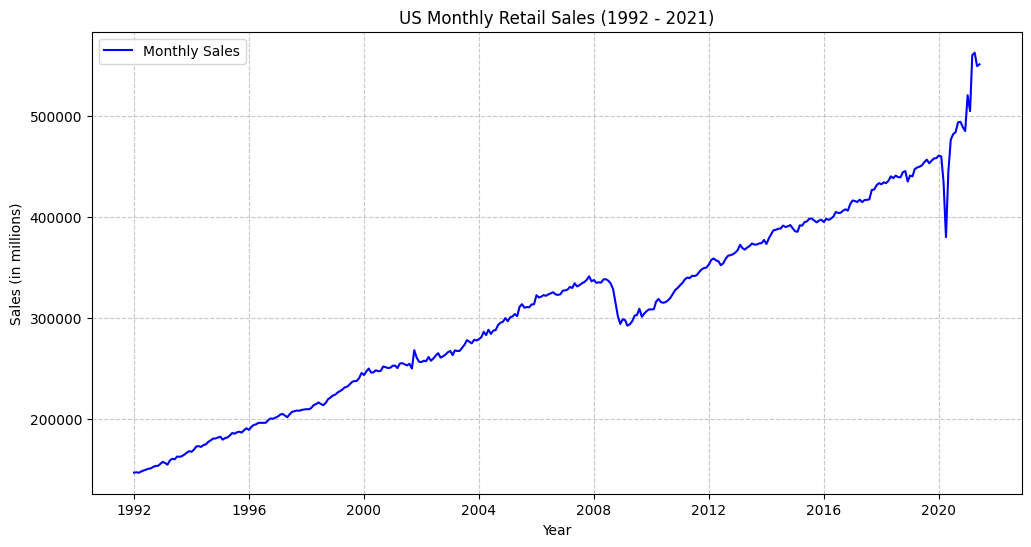

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(sales_series, color='blue', label='Monthly Sales')
plt.title('US Monthly Retail Sales (1992 - 2021)')
plt.xlabel('Year')
plt.ylabel('Sales (in millions)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.grid(True)

### Observations from the Plot
* Positive Trend: There is a clear and consistent long-term upward trend in retail sales over the nearly 30-year period.

* Seasonality: The data exhibits a very strong and regular seasonal pattern, with predictable peaks and troughs occurring annually.

* 2020-2021 Volatility: There is a notable "V-shaped" dip in early 2020 corresponding to the start of the COVID-19 pandemic, followed by a sharp and unprecedented surge in sales during 2021, which significantly deviates from previous growth slopes.

### Training and Test Split
For modeling purposes, the data was split into two parts. The most recent year (July 2020 to June 2021) was set aside as the test dataset, while all earlier observations were used to train the model.

In [17]:
train = sales_series[:'2020-06-01'].asfreq('MS')
test = sales_series['2020-07-01':'2021-06-01'].asfreq('MS')

### Model Development and Forecasting
A Holt-Winters exponential smoothing model was chosen because it can handle both trend and seasonal effects. Using additive components for these features, the model was trained on the historical data and then used to forecast sales for the following 12 months.

In [18]:
model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
predictions = model.forecast(len(test))

### Performance Evaluation

The accuracy of the model is evaluated by calculating the Root Mean Squared Error (RMSE) between the forecasted values and the actual observed values in the test set.

In [19]:
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f"RMSE: {rmse}")

RMSE: 41288.29142771892


The RMSE was about 41288. This relatively high value likely reflects how unusual retail activity was during 2020–2021, as models trained on past patterns struggled to anticipate such a sudden surge.